# Task II: Convolutional Neural Networks — AI vs. Human Art Classifier

## Setup Instructions
1. Upload `Art_shuffled.zip` to your Google Drive root folder
2. Mount Google Drive and run all cells in order

**Dataset:** `Art_shuffled/` — 539 AI-generated images, 436 real art images (975 total)  
**Model:** EfficientNetB0 via transfer learning, trained on Google Colab with T4 GPU  
**Note:** Full training takes approximately 20 minutes on Colab T4. EarlyStopping is used to avoid unnecessary epochs.

## 1. Mount Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
!rm -rf /content/Art_shuffled/
!unzip -o -q /content/drive/MyDrive/Art_shuffled.zip -d /content/

## 2. Exploratory Data Analysis

Before building the model, we inspect the dataset to understand its structure and any potential issues.

**Class distribution:** The dataset contains 539 AI-generated and 436 real art images — a mild imbalance of roughly 55/45. This is not severe enough to require resampling or class weighting, but it is worth keeping in mind when interpreting accuracy: a naive classifier that always predicts 'AI' would achieve ~55% accuracy, so our baseline for meaningful performance is clearly above that.

**Dataset size:** With fewer than 1000 images total, this is a small dataset. Training a deep CNN from scratch on this scale would almost certainly lead to severe overfitting. This motivates the use of transfer learning from a pretrained model.

In [ ]:
import os

dataset_path = '/content/Art_shuffled/'
ai_count = len(os.listdir(os.path.join(dataset_path, 'AiArtData/')))
real_count = len(os.listdir(os.path.join(dataset_path, 'RealArt/')))

print(f"AI images:    {ai_count}")
print(f"Real images:  {real_count}")
print(f"Total:        {ai_count + real_count}")
print(f"Class ratio:  {ai_count / (ai_count + real_count):.2%} AI / {real_count / (ai_count + real_count):.2%} Real")

## 3. Data Preprocessing and Augmentation

**Image size:** EfficientNetB0 expects 224×224 input, so all images are resized accordingly.

**Augmentation:** Because the dataset is small, we apply light augmentation during training to artificially increase variety and reduce overfitting:
- **Rotation (±15°):** Art images appear in various orientations
- **Horizontal flip:** Valid for visual art; does not alter class identity
- **Zoom (±10%):** Simulates variation in image framing

We deliberately keep augmentation conservative. Aggressive transformations (e.g., large colour jitter, vertical flips) could distort visual features that are actually informative for distinguishing AI from human art — such as brushstroke texture or compositional patterns.

**Validation split:** 20% of data is held out for validation (752 training / 186 validation images). The same `ImageDataGenerator` is used with `subset` parameter to ensure consistent splitting.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)

## 4. Model Architecture — Why EfficientNetB0?

### Choice of pretrained model

We use **EfficientNetB0** pretrained on ImageNet as our base model. This choice is justified by several factors:

- **Compound scaling:** EfficientNet models scale depth, width, and resolution jointly, giving strong performance per parameter. B0 is the smallest variant, making it appropriate for our compute constraints (Colab T4) without sacrificing too much capacity.
- **Small dataset suitability:** With fewer than 1000 images, training a deep network from scratch would overfit severely. Transfer learning leverages ImageNet features (edges, textures, shapes) that transfer well to art images.
- **Precedent:** EfficientNet has strong benchmark performance on image classification tasks at this scale.

An alternative would be **ResNet50** or **VGG16**, but these are larger models with more parameters — unnecessary given our dataset size, and slower to train on Colab.

### Architecture

The custom head added on top of the frozen base consists of:
- `GlobalAveragePooling2D` — reduces spatial feature maps to a single vector per feature, avoiding flattening which would produce very large parameter counts
- `Dense(128, relu)` — learns task-specific combinations of EfficientNet features
- `Dropout(0.3)` — regularization to reduce overfitting in the head
- `Dense(1, sigmoid)` — binary output (0 = AI art, 1 = Real art)

In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

model.summary()

## 5. Phase 1 — Training the Classification Head

In the first training phase, the EfficientNetB0 base is **frozen** — its weights are not updated. Only the custom head (Dense + Dropout + output) is trained. This is standard practice when fine-tuning: it allows the new layers to adapt to the task without disrupting the pretrained ImageNet features.

**Optimizer:** Adam with lr=1e-3. A relatively high learning rate is appropriate here since only the small head is being trained and convergence should be fast.

**EarlyStopping:** We monitor `val_loss` with a patience of 3 epochs. If validation loss does not improve for 3 consecutive epochs, training stops automatically. `restore_best_weights=True` ensures we keep the weights from the best epoch, not the final one. This prevents unnecessary training time and avoids overfitting into the validation set.

In [ ]:
early_stop_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,  # EarlyStopping will terminate this early if needed
    callbacks=[early_stop_phase1]
)

## 6. Phase 2 — Fine-Tuning the Top Layers of the Base Model

In the second phase, we **unfreeze the last 20 layers** of the EfficientNetB0 base and continue training. This allows the model to adapt higher-level ImageNet features (which encode general object patterns) toward features more relevant to distinguishing AI from human art — such as brushstroke regularity, noise distribution, or stylistic consistency.

**Why only the last 20 layers?** Earlier layers capture low-level features (edges, textures) that transfer well from ImageNet. Deeper layers are more task-specific. Unfreezing too many layers risks overfitting and is slower to train; unfreezing too few limits the model's ability to specialise.

**Optimizer:** Adam with lr=1e-5. A much lower learning rate is critical here — updating the pretrained weights too aggressively would destroy the learned representations (a phenomenon sometimes called 'catastrophic forgetting').

**EarlyStopping:** Applied again with patience=3 on val_loss.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

early_stop_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_phase2]
)

model.save('/content/drive/MyDrive/art_classifier.keras')
print("Model saved to Google Drive.")

## 7. Training History Visualisation

Plotting the training and validation accuracy/loss across both phases helps us diagnose overfitting and assess whether EarlyStopping triggered at the right point.

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_title(f'{title_prefix} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title(f'{title_prefix} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1 (Frozen Base)')
plot_history(history_phase2, 'Phase 2 (Fine-Tuning)')

## 8. Evaluation — Confusion Matrix and Classification Report

Accuracy alone is an incomplete metric. We also compute a **confusion matrix** and **precision/recall/F1** to understand whether errors are distributed evenly across classes or skewed.

Given the mild class imbalance (55% AI, 45% real), F1-score is a more informative summary than raw accuracy. A model that simply predicts 'AI' for every image would achieve ~55% accuracy — well below our model's performance, confirming it has learned meaningful features.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

val_data.reset()
y_pred_probs = model.predict(val_data, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_data.classes

print(classification_report(y_true, y_pred, target_names=['AI Art', 'Real Art']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AI Art', 'Real Art'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.show()

## Task 2b — Classifying 5 New Images

For Task 2b, three ai images and two real images was used.

The AI-generated images were created using Nano Banana Pro (Gemini 3 Pro Image) one of the most capable frontier image generation models currently available. Two real images were photographs taken from out smartphone.

The trained model was exported from Google Colab as art_classifier.keras and loaded locally. Each image was resized to 224×224, matching the preprocessing used during training. The model outputs a sigmoid score representing the probability of an image being real art - values below 0.5 are classified as AI-generated, and values above 0.5 as human-created.

Each image was resized to 224×224 and loaded as RGB, matching the preprocessing used during training. No manual pixel rescaling was applied, as EfficientNetB0 includes its own internal preprocessing when called with pretrained ImageNet weights.


In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

MODEL_PATH = Path("art_classifier.keras")
NEW_IMAGE_DIR = Path("task2_new_images")
IMG_SIZE = (224, 224)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif"}

assert MODEL_PATH.exists(), f"Could not find trained model: {MODEL_PATH}"
assert NEW_IMAGE_DIR.exists(), f"Could not find image folder: {NEW_IMAGE_DIR}"

model = load_model(MODEL_PATH)
print("Loaded trained model:", MODEL_PATH)

new_image_paths = sorted(
    p for p in NEW_IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
)

assert len(new_image_paths) == 5, (
    f"Expected exactly 5 new images, but found {len(new_image_paths)}. "
    "Place the images inside task2_new_images/AiArtData and task2_new_images/RealArt."
)

print("Images to classify:")
for path in new_image_paths:
    print(path)


Loaded trained model: art_classifier.keras
Images to classify:
task2_new_images/AiArtData/Screenshot 2026-04-22 at 13.21.45.png
task2_new_images/AiArtData/Screenshot 2026-04-22 at 13.21.56.png
task2_new_images/AiArtData/Screenshot 2026-04-22 at 15.23.13.png
task2_new_images/RealArt/IMG_8190.jpeg
task2_new_images/RealArt/IMG_8191.jpeg


In [21]:
# This must match the folder mapping used during training.
# In your training generator, this is normally:
# {'AiArtData': 0, 'RealArt': 1}
class_indices = {
    "AiArtData": 0,
    "RealArt": 1,
}
index_to_class = {v: k for k, v in class_indices.items()}

def prepare_image(image_path):
    image = load_img(image_path, target_size=IMG_SIZE)
    array = img_to_array(image)
    return array

image_batch = np.stack([prepare_image(path) for path in new_image_paths])

# The model has a sigmoid output:
# values close to 0 mean AiArtData, values close to 1 mean RealArt.
prob_real = model.predict(image_batch, verbose=0).reshape(-1)
predicted_indices = (prob_real >= 0.5).astype(int)

true_labels = [path.parent.name for path in new_image_paths]
true_indices = [class_indices[label] for label in true_labels]

results = pd.DataFrame({
    "image": [path.name for path in new_image_paths],
    "true_label": true_labels,
    "probability_real_art": prob_real,
    "predicted_label": [index_to_class[index] for index in predicted_indices],
})

results["correct"] = results["true_label"] == results["predicted_label"]
results["confidence"] = np.where(
    predicted_indices == 1,
    results["probability_real_art"],
    1 - results["probability_real_art"]
)

accuracy = accuracy_score(true_indices, predicted_indices)

print(f"Accuracy on 5 new images: {accuracy:.2%}")
display(results)

print(classification_report(
    true_indices,
    predicted_indices,
    labels=[0, 1],
    target_names=[index_to_class[0], index_to_class[1]],
    zero_division=0,
))


Accuracy on 5 new images: 0.00%


,image,true_label,probability_real_art,predicted_label,correct,confidence
0,Screenshot 2026-04-22 at 13.21.45.png,AiArtData,0.530706,RealArt,False,0.530706
1,Screenshot 2026-04-22 at 13.21.56.png,AiArtData,0.719515,RealArt,False,0.719515
2,Screenshot 2026-04-22 at 15.23.13.png,AiArtData,0.584395,RealArt,False,0.584395
3,IMG_8190.jpeg,RealArt,0.286279,AiArtData,False,0.713721
4,IMG_8191.jpeg,RealArt,0.487959,AiArtData,False,0.512041


              precision    recall  f1-score   support

   AiArtData       0.00      0.00      0.00       3.0
     RealArt       0.00      0.00      0.00       2.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



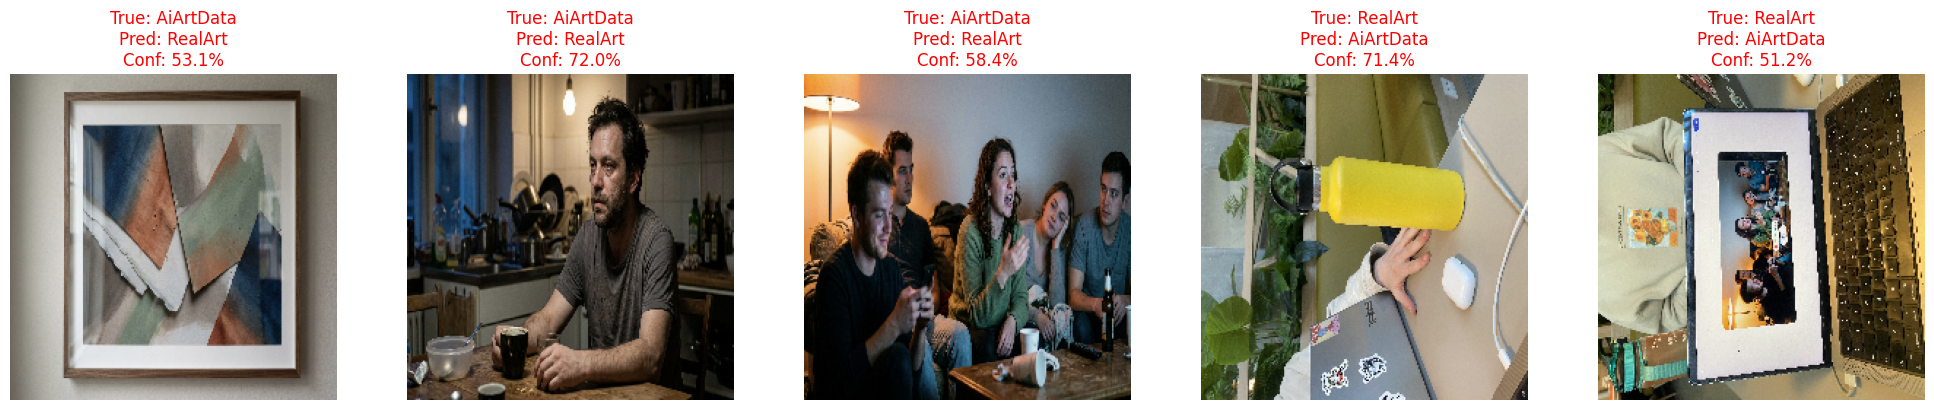

In [22]:
fig, axes = plt.subplots(1, len(new_image_paths), figsize=(4 * len(new_image_paths), 4))

if len(new_image_paths) == 1:
    axes = [axes]

for ax, image_path, (_, row) in zip(axes, new_image_paths, results.iterrows()):
    image = load_img(image_path, target_size=IMG_SIZE)
    ax.imshow(image)
    ax.axis("off")

    title_color = "green" if row["correct"] else "red"
    title = "\n".join([
        f"True: {row['true_label']}",
        f"Pred: {row['predicted_label']}",
        f"Conf: {row['confidence']:.1%}",
    ])
    ax.set_title(title, color=title_color)

plt.tight_layout()
plt.show()


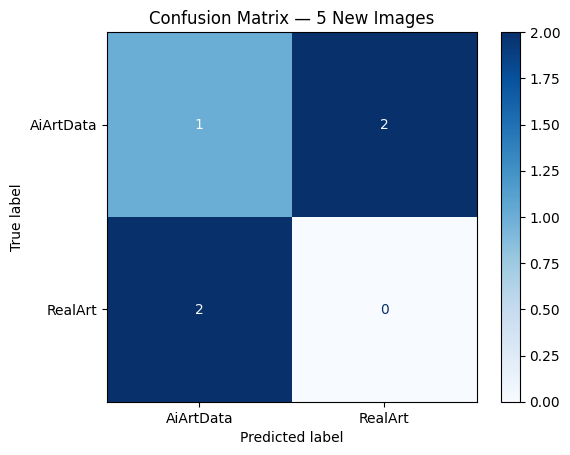

In [13]:
cm = confusion_matrix(true_indices, predicted_indices, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[index_to_class[0], index_to_class[1]]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — 5 New Images")
plt.show()


### Extra Test: Five AI-Generated Images

The folder `task2b_aiart_images/` contains five additional AI-generated images. Since these files are not organized into class subfolders, we manually set the true label for all five images to `AiArtData` and then compare the model predictions with that expected label.

In [14]:
AI_IMAGE_DIR = Path("task2b_aiart_images")

assert MODEL_PATH.exists(), f"Could not find trained model: {MODEL_PATH}"
assert AI_IMAGE_DIR.exists(), f"Could not find image folder: {AI_IMAGE_DIR}"

# Load the exported Colab model locally if it is not already loaded.
if "model" not in globals():
    model = load_model(MODEL_PATH, compile=False)
    print("Loaded trained model:", MODEL_PATH)

ai_image_paths = sorted(
    p for p in AI_IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
)

assert len(ai_image_paths) == 5, (
    f"Expected exactly 5 AI-generated images, but found {len(ai_image_paths)}."
)

ai_image_batch = np.stack([prepare_image(path) for path in ai_image_paths])
ai_prob_real = model.predict(ai_image_batch, verbose=0).reshape(-1)
ai_predicted_indices = (ai_prob_real >= 0.5).astype(int)

ai_true_labels = ["AiArtData"] * len(ai_image_paths)
ai_true_indices = [class_indices[label] for label in ai_true_labels]

ai_results = pd.DataFrame({
    "image": [path.name for path in ai_image_paths],
    "true_label": ai_true_labels,
    "probability_real_art": ai_prob_real,
    "predicted_label": [index_to_class[index] for index in ai_predicted_indices],
})

ai_results["correct"] = ai_results["true_label"] == ai_results["predicted_label"]
ai_results["confidence"] = np.where(
    ai_predicted_indices == 1,
    ai_results["probability_real_art"],
    1 - ai_results["probability_real_art"]
)

ai_accuracy = accuracy_score(ai_true_indices, ai_predicted_indices)
print(f"Accuracy on the five AI-generated images: {ai_accuracy:.2%}")
display(ai_results)

print(classification_report(
    ai_true_indices,
    ai_predicted_indices,
    labels=[0, 1],
    target_names=[index_to_class[0], index_to_class[1]],
    zero_division=0,
))

/Users/ferdinandhaldorsen/Projects/ai/info284/Group-Exam-INFO284/.venv/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Accuracy on the five AI-generated images: 100.00%


,image,true_label,probability_real_art,predicted_label,correct,confidence
0,aiart.jpeg,AiArtData,0.029171,AiArtData,True,0.970829
1,aiart.webp,AiArtData,0.069511,AiArtData,True,0.930489
2,aiart1.jpeg,AiArtData,0.022182,AiArtData,True,0.977818
3,aiart2.png,AiArtData,0.052266,AiArtData,True,0.947734
4,airart3.jpeg,AiArtData,0.379872,AiArtData,True,0.620128


              precision    recall  f1-score   support

   AiArtData       1.00      1.00      1.00         5
     RealArt       0.00      0.00      0.00         0

    accuracy                           1.00         5
   macro avg       0.50      0.50      0.50         5
weighted avg       1.00      1.00      1.00         5



/Users/ferdinandhaldorsen/Projects/ai/info284/Group-Exam-INFO284/.venv/lib/python3.11/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


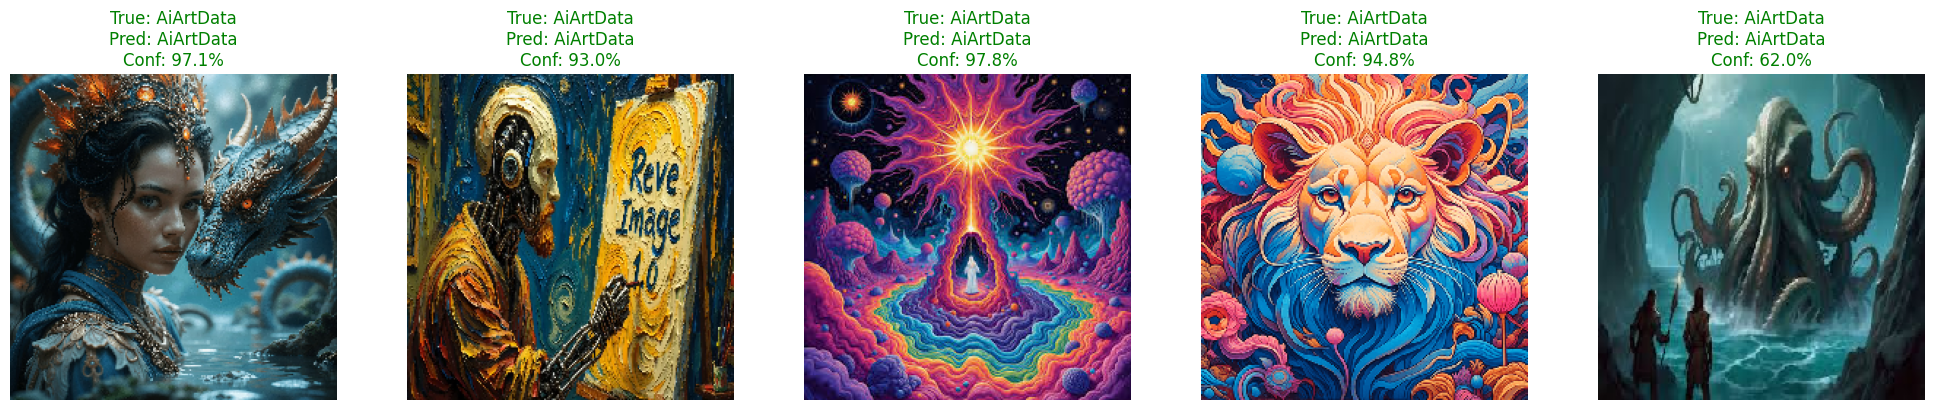

In [18]:
fig, axes = plt.subplots(1, len(ai_image_paths), figsize=(4 * len(ai_image_paths), 4))

if len(ai_image_paths) == 1:
    axes = [axes]

for ax, image_path, (_, row) in zip(axes, ai_image_paths, ai_results.iterrows()):
    image = load_img(image_path, target_size=IMG_SIZE)
    ax.imshow(image)
    ax.axis("off")

    title_color = "green" if row["correct"] else "red"
    title = "\n".join([
        f"True: {row['true_label']}",
        f"Pred: {row['predicted_label']}",
        f"Conf: {row['confidence']:.1%}",
    ])
    ax.set_title(title, color=title_color)

plt.tight_layout()
plt.show()


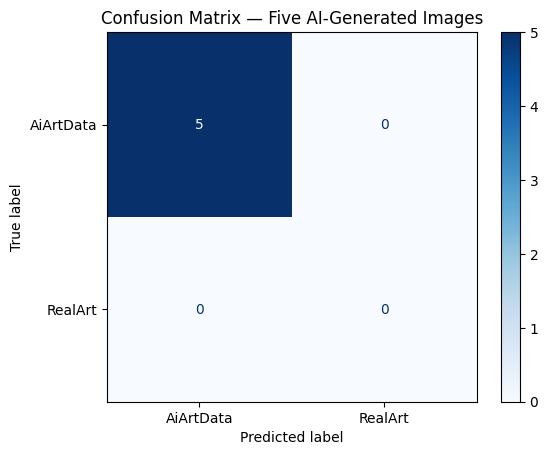

In [17]:
ai_cm = confusion_matrix(ai_true_indices, ai_predicted_indices, labels=[0, 1])

ai_disp = ConfusionMatrixDisplay(
    confusion_matrix=ai_cm,
    display_labels=[index_to_class[0], index_to_class[1]]
)

ai_disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Five AI-Generated Images")
plt.show()